# 07. EDA: Correlaciones e Impacto de la Vegetación y Pendiente

Este notebook cierra la **Fase 2: Análisis Exploratorio de Datos (EDA)**. Su objetivo es profundizar en dos factores determinantes para el comportamiento y la propagación de incendios en la Comunitat Valenciana:
1. **Auditoría de Multicolinealidad (Correlación):** Analizar si las variables climáticas y topográficas presentan alta correlación entre sí, lo que podría sesgar nuestros futuros modelos de machine learning.
2. **Vegetación (Combustible) vs. Severidad:** Evaluar empíricamente cómo el tipo de combustible vegetal (COSCV 2024) condiciona el tamaño final de los incendios.
3. **Pendiente vs. Severidad por Tipo de Bosque:** Investigar la relación entre la inclinación del terreno y el combustible vegetal como catalizadores de mega-incendios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 100


FIG_DIR = Path("../entregas/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)


DATA_PATH = Path("../datos/processed/07_dataset_final_TOPOGRAFICO.csv")
df = pd.read_csv(DATA_PATH, sep=';', decimal=',') 
df = df.drop_duplicates(subset=['lat', 'lon', 'fecha_ini', 'Superficie_Total_Real'])


cols_numericas = ['Superficie_Total_Real', 'temp_max', 'racha_max', 'temp_media', 'temp_min', 
                 'precipitacion', 'humedad_media', 'viento_medio', 'pendiente', 'orientacion', 
                 'elevacion', 'prec_acum_7d', 'dias_sin_lluvia']

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')


df = df.dropna(subset=['Superficie_Total_Real', 'pendiente', 'tipo_vegetacion'])


df['log_superficie'] = np.log1p(df['Superficie_Total_Real'])


df['es_GIF'] = df['Superficie_Total_Real'] > 500


df['tipo_vegetacion'] = df['tipo_vegetacion'].str.replace(r'Con.*feras', 'Coníferas', regex=True)
df['tipo_vegetacion'] = df['tipo_vegetacion'].str.replace(r'Agr.*cola', 'Agrícola', regex=True)
df['tipo_vegetacion'] = df['tipo_vegetacion'].replace('Urbano/Antropizado', 'Urbano/Otros')

print(f"Dataset cargado y depurado con éxito. Registros útiles: {len(df)}")
print(f"Distribución de categorías en tipo_vegetacion:")
print(df['tipo_vegetacion'].value_counts())

Dataset cargado y depurado con éxito. Registros útiles: 4443
Distribución de categorías en tipo_vegetacion:
tipo_vegetacion
Coníferas       1353
Matorral        1030
Urbano/Otros     699
Agrícola         555
Frondosas        550
Pastizal         256
Name: count, dtype: int64


## 1. Auditoría de Multicolinealidad (Matriz de Correlación)

Para evitar la multicolinealidad en el modelado predictivo, es vital auditar la correlación entre nuestras variables climatológicas e hídricas. Dado que las variables forestales y climáticas en la región mediterránea suelen seguir distribuciones marcadamente asimétricas con outliers significativos, utilizaremos el **coeficiente de correlación de Spearman** (que mide relaciones monótonas no lineales basándose en rangos).

Representaremos esta matriz mediante un mapa de calor triangular para una lectura limpia y libre de duplicidades.

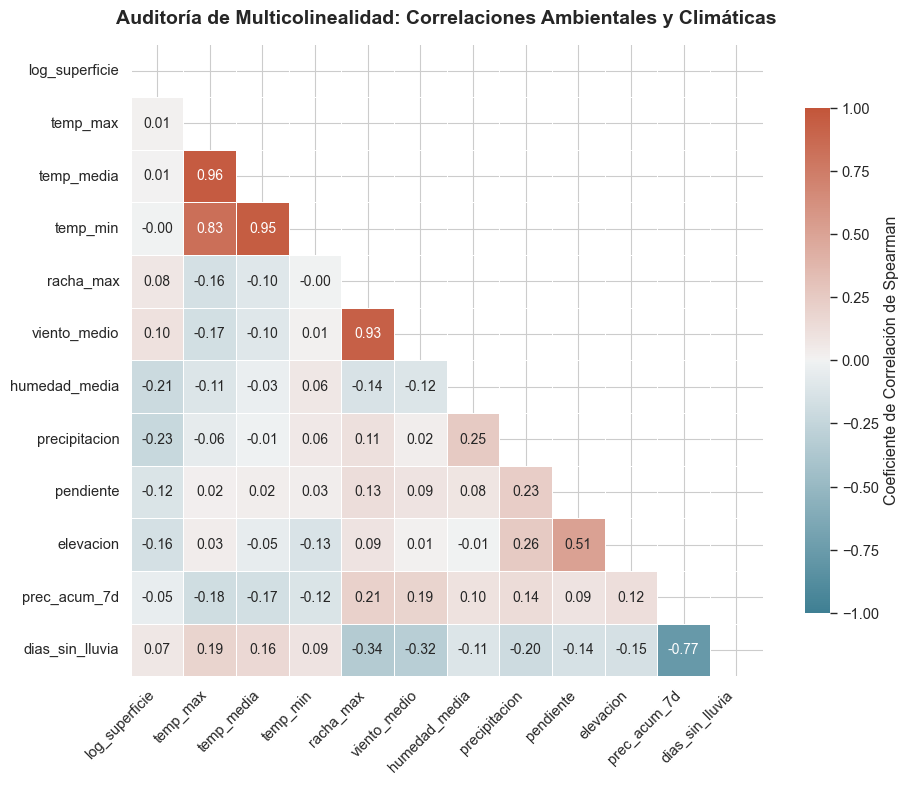

In [2]:

cols_corr = ['log_superficie', 'temp_max', 'temp_media', 'temp_min', 
             'racha_max', 'viento_medio', 'humedad_media', 'precipitacion', 
             'pendiente', 'elevacion', 'prec_acum_7d', 'dias_sin_lluvia']


corr_matrix = df[cols_corr].corr(method='spearman')


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1.0, 
    vmax=1.0, 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación de Spearman"},
    annot_kws={"size": 10}
)

plt.title('Auditoría de Multicolinealidad: Correlaciones Ambientales y Climáticas', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


plt.savefig(FIG_DIR / '09_Matriz_Correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Vegetación (Combustible COSCV 2024) vs. Severidad de Incendios

La distribución de los tipos de combustible (vegetación) es el pilar central de la planificación silvícola y la prevención de incendios. Diferentes formaciones vegetales presentan distinta inflamabilidad y combustibilidad. Evaluaremos cómo varía la variable de severidad (`log_superficie`) según el tipo de vegetación utilizando un gráfico combinado estético que superpone diagramas de cajas (`boxplot`) y nubes de puntos individuales (`stripplot`).

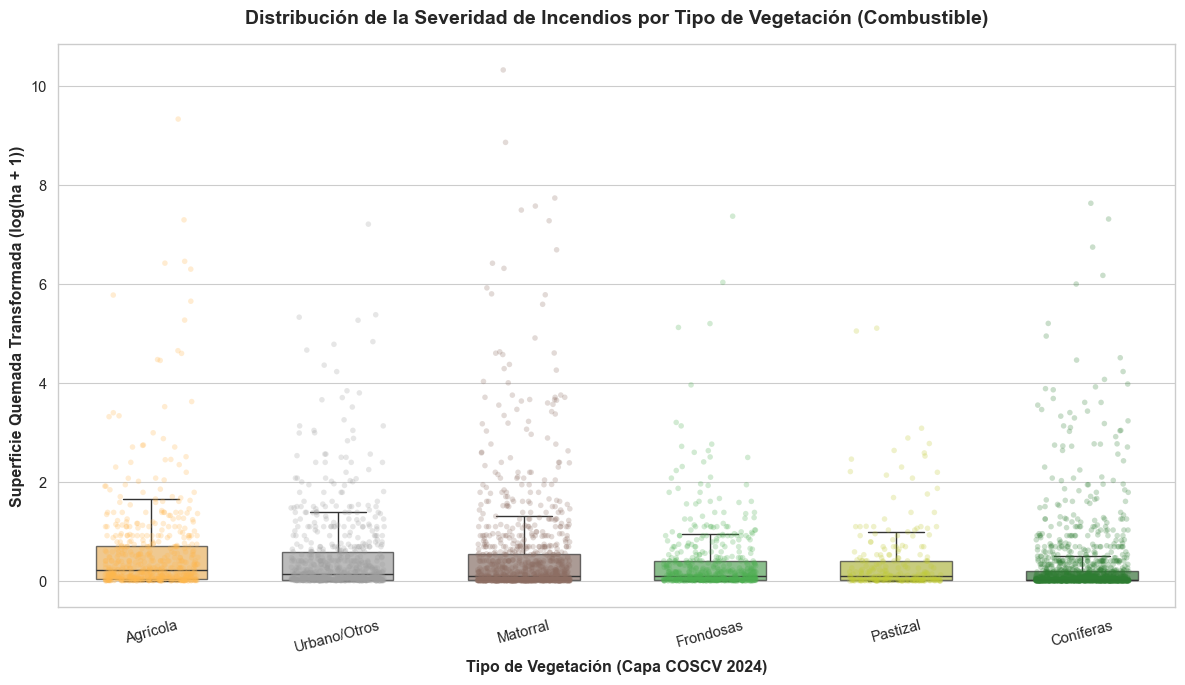

In [3]:

colores_vegetacion = {
    'Coníferas': '#2e7d32',   
    'Matorral': '#8d6e63',    
    'Frondosas': '#4caf50',   
    'Pastizal': '#c0ca33',    
    'Agrícola': '#ffb74d',    
    'Urbano/Otros': '#9e9e9e' 
}


order = df.groupby('tipo_vegetacion')['log_superficie'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))


sns.boxplot(
    data=df,
    x='tipo_vegetacion',
    y='log_superficie',
    order=order,
    palette=colores_vegetacion,
    width=0.6,
    fliersize=0, 
    boxprops=dict(alpha=0.7)
)


sns.stripplot(
    data=df,
    x='tipo_vegetacion',
    y='log_superficie',
    order=order,
    palette=colores_vegetacion,
    size=4,
    alpha=0.25,
    jitter=0.25,
    dodge=False
)

plt.title('Distribución de la Severidad de Incendios por Tipo de Vegetación (Combustible)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Vegetación (Capa COSCV 2024)', fontweight='bold')
plt.ylabel('Superficie Quemada Transformada (log(ha + 1))', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()


plt.savefig(FIG_DIR / '10_Vegetacion_Severidad.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Pendiente vs. Severidad por Tipo de Bosque

La física del fuego enseña que el relieve condiciona fuertemente la propagación: a mayor pendiente, la llama se inclina más hacia el combustible no quemado, acelerando la transferencia de calor por radiación y convección. Cruzaremos la variable de **pendiente** (grados/porcentaje) frente a la **superficie quemada** (`log_superficie`), coloreando los puntos según el tipo de vegetación para ver cómo actúan ambos factores de forma conjunta.

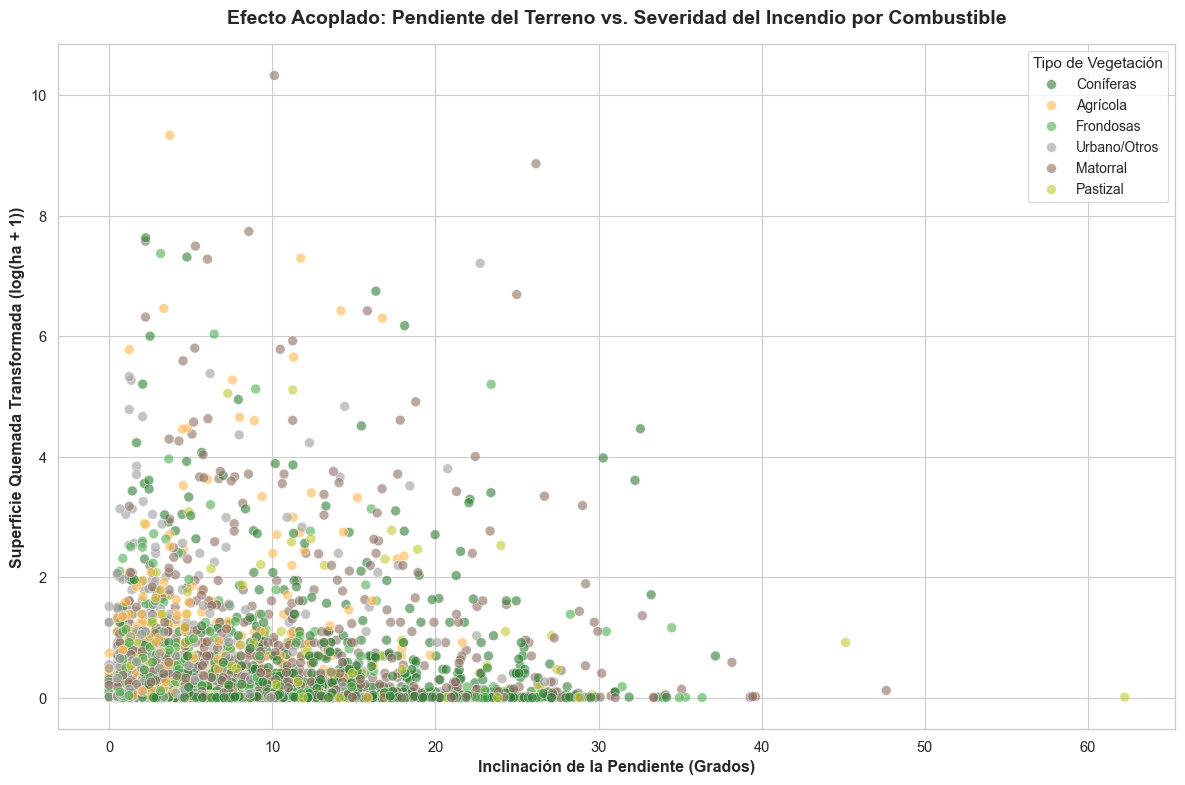

In [4]:
plt.figure(figsize=(12, 8))


sns.scatterplot(
    data=df,
    x='pendiente',
    y='log_superficie',
    hue='tipo_vegetacion',
    palette=colores_vegetacion,
    alpha=0.6,
    s=50,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Efecto Acoplado: Pendiente del Terreno vs. Severidad del Incendio por Combustible', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Inclinación de la Pendiente (Grados)', fontweight='bold')
plt.ylabel('Superficie Quemada Transformada (log(ha + 1))', fontweight='bold')
plt.legend(title='Tipo de Vegetación', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()


plt.savefig(FIG_DIR / '11_Pendiente_Vegetacion.png', dpi=300, bbox_inches='tight')
plt.show()